In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,)

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
from boolean_analysis import calculate_fourier_transform_matrix, parity_of_1s
import pandas as pd
from tqdm import tqdm
import pickle
from boolean_fourier_learner import BooleanFourierLearner
from pathlib import Path
import lzma
import parse
from spin_lattices import KagomeLattice
from utils import make_unpacked_configurations
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df, HeisenbergJ1J2
import lattice_symmetries as ls
import seaborn as sns

%matplotlib inline

In [3]:
experiment_dir = Path("kagome24-2023-01-02")

In [4]:
learners = {}
for file in experiment_dir.glob("fourier-learner-*.pickle.lz"):
    J, i = parse.search("fourier-learner-{}-{:d}.pickle.lz", str(file)).fixed
    J = float(J)
    with lzma.open(file) as f:
        learners[J, i] = pickle.load(f)

learners_ser = (
    pd.DataFrame(dict(learner=learners))
    .reset_index()
    .rename(columns={"level_0": "J", "level_1": "iterations"})
).set_index(["J", "iterations"])["learner"]

for learner in learners.values():
    learner.coeffs_df_ = None

In [5]:
train_sets = {}
for file in experiment_dir.glob("train-*.feather"):
    (J,) = parse.search("train-{}.feather", str(file)).fixed
    J = float(J)
    train_sets[J] = pd.read_feather(file).set_index("index")

In [ ]:
index = learners_ser[0.0, 400].get_coeffs_df().iloc[:20].index
for i in range(0, 500, 400):
    learners_ser[0.0, i].get_coeffs_df().loc[index].plot.bar()

In [6]:
lat = KagomeLattice(width=2, height=4)

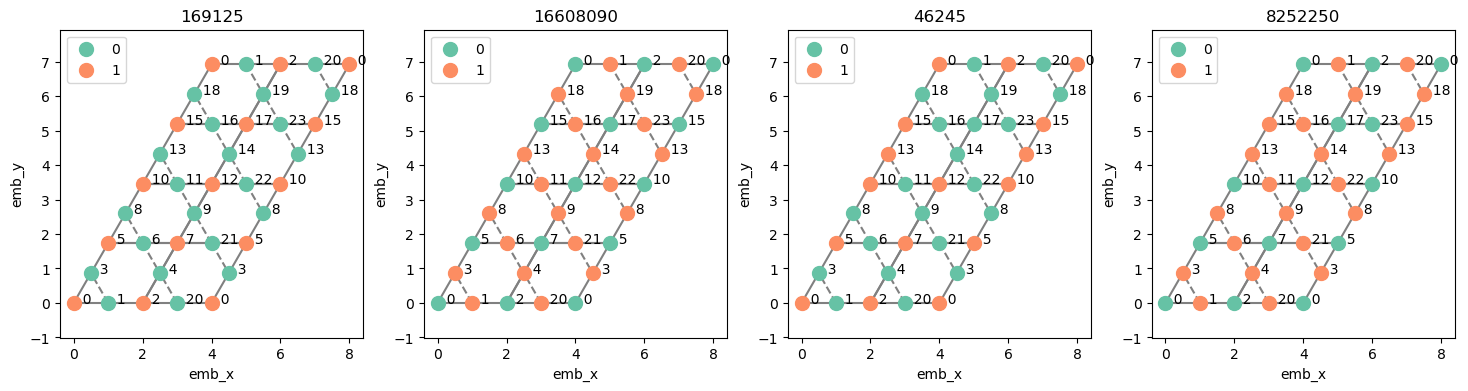

In [93]:
fig, axes = plt.subplots(ncols=4, figsize=(18, 4))
for i, ax in enumerate(axes):
    spins = int(learners_ser[0.2, 200].get_coeffs_df().index[i])
    lat.plot(spins=spins, ax=ax)
    ax.set_title(spins)

In [7]:
system = HeisenbergJ1J2(lat, J1=1, J2=0, use_symmetries=True)

fourier_basis = ls.SpinBasis(
    system.symmetry_group,
    number_spins=system.number_spins,
    hamming_weight=None,
    spin_inversion=None,
)
fourier_basis.build()

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


In [8]:
state_info_df = batched_state_info_df(
    fourier_basis, np.arange(2**system.number_spins, dtype="uint64")
)

In [8]:
multiplicities = (
    state_info_df.reset_index()
    .rename(columns={"index": "subset"})
    .groupby("representative")
    .size()
)

In [13]:
learners_ser[1.2, 400].get_coeffs_df().assign(
    multiplicities=multiplicities
).iloc[:10]

,coeff,multiplicities
15833190,-0.14092,2
3382374,-0.13592,8
848700,-0.13572,2
848730,-0.13004,8
7572646,-0.12696,4
1993528,-0.12308,4
3762597,-0.12024,8
242487,-0.11556,8
1635149,0.11436,16
1665869,0.11340,8


In [14]:
multiplicities.value_counts()

16    1041432
8       14022
4         506
2          48
1           8
dtype: int64

In [9]:
from boolean_analysis import calculate_fourier_transform_matrix

In [10]:
def expand_fourier_coeffs(coeffs, fourier_basis, number_spins):
    state_info_df = batched_state_info_df(
        fourier_basis, np.arange(2**number_spins, dtype="uint64")
    )
    return state_info_df.join(coeffs, on="representative")["coeff"].dropna()

In [11]:
def predict(coeffs, x, number_spins):
    transform_matrix = calculate_fourier_transform_matrix(
        states=x,
        subsets=np.array(coeffs.index, dtype="uint64"),
        number_spins=number_spins,
        show_progress=True,
    )
    return transform_matrix @ coeffs

In [12]:
state_info_df_system = (
    batched_state_info_df(system.basis, system.canonical_basis.states)
    .reset_index()
    .rename(columns={"index": "state"})
)
state_info_df_system

,state,representative,character,norm
0,4095,4095,1.0+0.0j,0.176777
1,6143,6143,1.0+0.0j,0.176777
2,7167,7167,1.0+0.0j,0.176777
3,7679,7679,1.0+0.0j,0.176777
4,7935,7935,1.0+0.0j,0.176777
...,...,...,...,...
2704151,16769280,7935,1.0+0.0j,0.176777
2704152,16769536,7679,1.0+0.0j,0.176777
2704153,16770048,7167,1.0+0.0j,0.176777
2704154,16771072,6143,1.0+0.0j,0.176777


In [13]:
def mk_test_set(system, train, size=10000):
    state_info_df_system = (
        batched_state_info_df(system.basis, system.canonical_basis.states)
        .reset_index()
        .rename(columns={"index": "state"})
    )
    return np.random.choice(
        state_info_df_system.merge(
            batched_state_info_df(system.basis, np.array(train))
            .reset_index()
            .rename(columns={"index": "train_state"}),
            on="representative",
            how="outer",
        )[lambda x: x["train_state"].isnull()]["state"],
        size=size,
        replace=False,
    )

In [15]:
mk_test_set(system, train_sets[0.5].index).shape

(10000,)

In [14]:
def sign_overlap(sign_pred, eigenstate):
    amplitudes = np.abs(eigenstate)
    return (np.sign(sign_pred) * amplitudes * eigenstate).sum() / (
        amplitudes**2
    ).sum()

In [17]:
learners_ser

J     iterations
0.00  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
      150           <boolean_fourier_learner.BooleanFourierLearner...
      200           <boolean_fourier_learner.BooleanFourierLearner...
0.20  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
      150           <boolean_fourier_learner.BooleanFourierLearner...
      200           <boolean_fourier_learner.BooleanFourierLearner...
0.40  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
      150           <boolean_fourier_learner.BooleanFourierLearner...
      200           <boolean_fourier_learner.BooleanFourierLearner...
0.50  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
   

In [15]:
batch_size = 100


def calculate_overlap(keep_coeffs=100, test_set_size=1000):
    datapoints = []

    if isinstance(keep_coeffs, int):
        keep_coeffs = [keep_coeffs]

    for keep_coeff in tqdm(keep_coeffs):
        for (J2, iterations), learner in tqdm(learners_ser.items()):
            system = HeisenbergJ1J2(lat, J1=1, J2=J2, use_symmetries=True)
            system.get_eigenstates()

            train = train_sets[J2]

            train_set_size = batch_size * iterations
            train_eps = train_set_size / len(system.canonical_basis.states)

            test_states = mk_test_set(system, train.index, size=test_set_size)
            coeffs_expanded = expand_fourier_coeffs(
                learner.get_coeffs_df().iloc[:keep_coeff],
                fourier_basis,
                system.number_spins,
            )

            coeffs_kept_full = len(coeffs_expanded)

            coeffs_eps = coeffs_kept_full / 2**system.number_spins

            prediction = predict(
                coeffs_expanded,
                test_states,
                system.number_spins,
            )

            test_eigenstate = system.get_df_eigenstate(
                k=0, canonical_basis=True
            ).loc[test_states, "eigenstate_coeff"]

            overlap = sign_overlap(prediction, test_eigenstate)
            datapoints.append(
                [
                    J2,
                    iterations,
                    train_set_size,
                    train_eps,
                    test_set_size,
                    keep_coeff,
                    coeffs_kept_full,
                    coeffs_eps,
                    overlap,
                ]
            )
    df = pd.DataFrame(
        datapoints,
        columns=[
            "J2",
            "iterations",
            "train_set_size",
            "train_eps",
            "test_set_size",
            "keep_coeff",
            "coeffs_kept_fill",
            "coeffs_eps",
            "overlap",
        ],
    )
    return df

In [16]:
overlap_df_full = calculate_overlap(keep_coeffs=[2, 100, 2000])

  0%|          | 0/3 [00:00<?, ?it/s]
0it [00:00, ?it/s]

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314




100%|██████████| 24/24 [00:00<00:00, 27369.03it/s]

1it [00:12, 12.95s/it]

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314




100%|██████████| 24/24 [00:00<00:00, 27361.59it/s]

2it [00:26, 13.05s/it]

...



  0%|          | 0/24 [00:00<?, ?it/s]

  4%|▍         | 1/24 [00:00<00:04,  4.80it/s]

  8%|▊         | 2/24 [00:00<00:04,  4.69it/s]

 12%|█▎        | 3/24 [00:00<00:04,  4.65it/s]

 17%|█▋        | 4/24 [00:00<00:04,  4.63it/s]

 21%|██        | 5/24 [00:01<00:04,  4.63it/s]

 25%|██▌       | 6/24 [00:01<00:03,  4.62it/s]

 29%|██▉       | 7/24 [00:01<00:03,  4.62it/s]

 33%|███▎      | 8/24 [00:01<00:03,  4.62it/s]

 38%|███▊      | 9/24 [00:01<00:03,  4.61it/s]

 42%|████▏     | 10/24 [00:02<00:03,  4.61it/s]

 46%|████▌     | 11/24 [00:02<00:02,  4.59it/s]

 50%|█████     | 12/24 [00:02<00:02,  4.57it/s]

 54%|█████▍    | 13/24 [00:02<00:02,  4.59it/s]

 58%|█████▊    | 14/24 [00:03<00:02,  4.59it/s]

 62%|██████▎   | 15/24 [00:03<00:01,  4.61it/s]

 67%|██████▋   | 16/24 [00:03<00:01,  4.61it/s]

 71%|███████   | 17/24 [00:03<00:01,  4.61it/s]

 75%|███████▌  | 18/24 [00:03<00:01,  4.61it/s]

 79%|███████▉  | 19/24 [00:04<00:01,  4.62it/s]

 83%|████████▎ | 20/24 [00:04<00:00,

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763




  0%|          | 0/24 [00:00<?, ?it/s]

  4%|▍         | 1/24 [00:00<00:04,  4.74it/s]

  8%|▊         | 2/24 [00:00<00:04,  4.66it/s]

 12%|█▎        | 3/24 [00:00<00:04,  4.62it/s]

 17%|█▋        | 4/24 [00:00<00:04,  4.61it/s]

 21%|██        | 5/24 [00:01<00:04,  4.60it/s]

 25%|██▌       | 6/24 [00:01<00:03,  4.59it/s]

 29%|██▉       | 7/24 [00:01<00:03,  4.59it/s]

 33%|███▎      | 8/24 [00:01<00:03,  4.59it/s]

 38%|███▊      | 9/24 [00:01<00:03,  4.59it/s]

 42%|████▏     | 10/24 [00:02<00:03,  4.60it/s]

 46%|████▌     | 11/24 [00:02<00:02,  4.59it/s]

 50%|█████     | 12/24 [00:02<00:02,  4.59it/s]

 54%|█████▍    | 13/24 [00:02<00:02,  4.60it/s]

 58%|█████▊    | 14/24 [00:03<00:02,  4.59it/s]

 62%|██████▎   | 15/24 [00:03<00:01,  4.59it/s]

 67%|██████▋   | 16/24 [00:03<00:01,  4.59it/s]

 71%|███████   | 17/24 [00:03<00:01,  4.59it/s]

 75%|███████▌  | 18/24 [00:03<00:01,  4.59it/s]

 79%|███████▉  | 19/24 [00:04<00:01,  4.59it/s]

 83%|████████▎ | 20/24 [00:04<00:00,

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763




  0%|          | 0/24 [00:00<?, ?it/s]

  4%|▍         | 1/24 [00:00<00:04,  4.76it/s]

  8%|▊         | 2/24 [00:00<00:04,  4.68it/s]

 12%|█▎        | 3/24 [00:00<00:04,  4.65it/s]

 17%|█▋        | 4/24 [00:00<00:04,  4.63it/s]

 21%|██        | 5/24 [00:01<00:04,  4.62it/s]

 25%|██▌       | 6/24 [00:01<00:03,  4.62it/s]

 29%|██▉       | 7/24 [00:01<00:03,  4.61it/s]

 33%|███▎      | 8/24 [00:01<00:03,  4.61it/s]

 38%|███▊      | 9/24 [00:01<00:03,  4.53it/s]

 42%|████▏     | 10/24 [00:02<00:03,  4.51it/s]

 46%|████▌     | 11/24 [00:02<00:02,  4.49it/s]

 50%|█████     | 12/24 [00:02<00:02,  4.53it/s]

 54%|█████▍    | 13/24 [00:02<00:02,  4.55it/s]

 58%|█████▊    | 14/24 [00:03<00:02,  4.56it/s]

 62%|██████▎   | 15/24 [00:03<00:01,  4.58it/s]

 67%|██████▋   | 16/24 [00:03<00:01,  4.60it/s]

 71%|███████   | 17/24 [00:03<00:01,  4.60it/s]

 75%|███████▌  | 18/24 [00:03<00:01,  4.59it/s]

 79%|███████▉  | 19/24 [00:04<00:01,  4.60it/s]

 83%|████████▎ | 20/24 [00:04<00:00,

In [17]:
overlap_df_full.to_feather(experiment_dir / "overlap.feather")

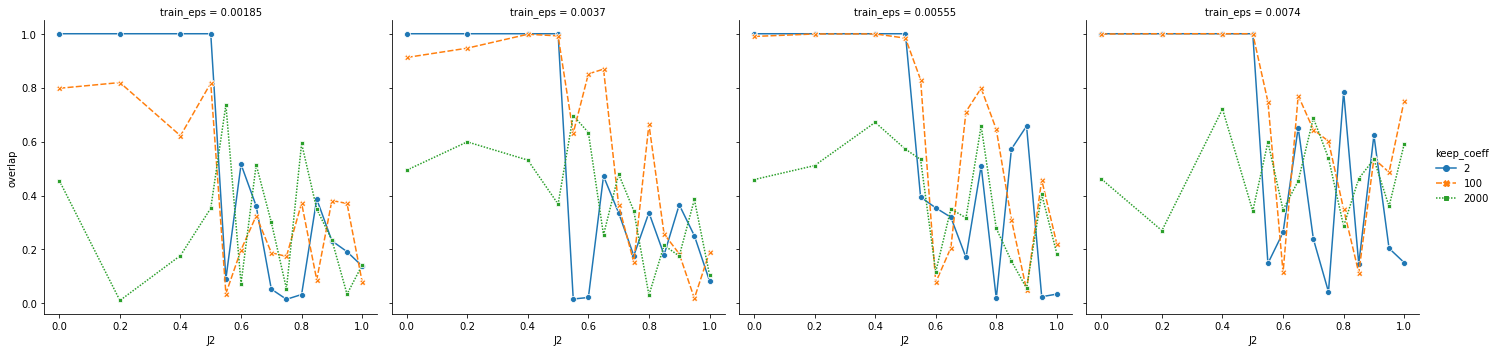

In [20]:
sns.relplot(
    overlap_df_full.assign(
        keep_eps=lambda x: np.round(
            (x["keep_coeff"] / len(fourier_basis.states)), 5
        ).astype(str),
        keep_coeff=lambda x: x["keep_coeff"].astype("str"),
        train_eps=lambda x: np.round(x["train_eps"], 5),
        overlap=lambda x: np.abs(x["overlap"]),
    )
    # .assign(iterations=lambda x: x["iterations"].astype(str))
    ,
    x="J2",
    y="overlap",
    hue="keep_coeff",
    style="keep_coeff",
    markers=True,
    col="train_eps",
    kind="line",
)  # .set(ylim=(0, None))
plt.savefig("kagome24-predict.pdf")

In [19]:
overlap_df_full

,J2,iterations,train_set_size,train_eps,test_set_size,keep_coeff,coeffs_kept_fill,coeffs_eps,overlap
0,0.00,50,5000,0.001849,1000,2,2,1.192093e-07,1.000000
1,0.00,100,10000,0.003698,1000,2,2,1.192093e-07,1.000000
2,0.00,150,15000,0.005547,1000,2,2,1.192093e-07,1.000000
3,0.00,200,20000,0.007396,1000,2,2,1.192093e-07,1.000000
4,0.20,50,5000,0.001849,1000,2,2,1.192093e-07,1.000000
...,...,...,...,...,...,...,...,...,...
163,0.95,200,20000,0.007396,1000,2000,31696,1.889229e-03,0.359636
164,1.00,50,5000,0.001849,1000,2000,31776,1.893997e-03,0.142231
165,1.00,100,10000,0.003698,1000,2000,31690,1.888871e-03,-0.106220
166,1.00,150,15000,0.005547,1000,2000,31718,1.890540e-03,0.184069


In [36]:
learner_multipliticities = []
for keep_first in [5, 10, 20, 100]:
    for J2, learner in learners_ser.swaplevel()[400].items():
        mean_multiplicity = (
            learner.get_coeffs_df()
            .assign(multiplicities=multiplicities)
            .iloc[:keep_first]["multiplicities"]
            .mean()
        )
        learner_multipliticities.append([J2, keep_first, mean_multiplicity])

learner_multipliticities = pd.DataFrame(
    learner_multipliticities,
    columns=["J2", "keep_first", "mean_multiplicity"],
)

In [50]:
(
    learner.get_coeffs_df()
    .iloc[:100]
    .reset_index()
    .assign(abs_coeff=lambda x: np.abs(x["coeff"]))
)

,index,coeff,abs_coeff
0,15833190,-0.14092,0.14092
1,3382374,-0.13592,0.13592
2,848700,-0.13572,0.13572
3,848730,-0.13004,0.13004
4,7572646,-0.12696,0.12696
...,...,...,...
95,5475214,0.08548,0.08548
96,3765061,0.08532,0.08532
97,3335782,0.08504,0.08504
98,15820902,-0.08488,0.08488


In [53]:
(
    learner.get_coeffs_df()
    .iloc[:100]
    .reset_index(drop=True)
    .reset_index()
    .assign(abs_coeff=lambda x: np.abs(x["coeff"]))
)

,index,coeff,abs_coeff
0,0,-0.14092,0.14092
1,1,-0.13592,0.13592
2,2,-0.13572,0.13572
3,3,-0.13004,0.13004
4,4,-0.12696,0.12696
...,...,...,...
95,95,0.08548,0.08548
96,96,0.08532,0.08532
97,97,0.08504,0.08504
98,98,-0.08488,0.08488


<AxesSubplot: xlabel='index', ylabel='abs_coeff'>

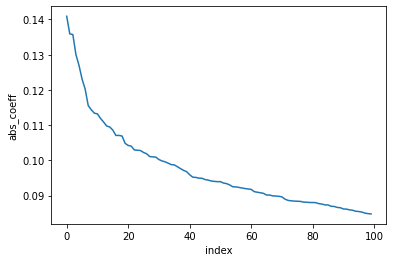

In [51]:
sns.lineplot(
    learner.get_coeffs_df()
    .iloc[:100]
    .reset_index(drop=True)
    .reset_index()
    .assign(abs_coeff=lambda x: np.abs(x["coeff"])),
    x="index",
    y="abs_coeff",
)

In [18]:
learners_ser

J     iterations
0.00  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
      150           <boolean_fourier_learner.BooleanFourierLearner...
      200           <boolean_fourier_learner.BooleanFourierLearner...
0.20  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
      150           <boolean_fourier_learner.BooleanFourierLearner...
      200           <boolean_fourier_learner.BooleanFourierLearner...
0.40  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
      150           <boolean_fourier_learner.BooleanFourierLearner...
      200           <boolean_fourier_learner.BooleanFourierLearner...
0.50  50            <boolean_fourier_learner.BooleanFourierLearner...
      100           <boolean_fourier_learner.BooleanFourierLearner...
   

In [58]:
first_coeffs = []
keep_coeffs = 10
step = None
for J2, learner in learners_ser.swaplevel()[200].items():
    coeffs = (
        learner.get_coeffs_df()
        .reset_index()
        .rename(columns={"index": "state"})
        .iloc[2:keep_coeffs:step]
        .reset_index()
        .assign(abs_coeff=lambda x: np.abs(x["coeff"]), J2=J2)
        .assign(
            degree=lambda x: make_unpacked_configurations(
                x["state"], system.number_spins
            ).sum(axis=1)
        )
        .assign(
            degree=lambda x: np.minimum(
                x["degree"], system.number_spins - x["degree"]
            )
        )
    )

    first_coeffs.append(coeffs)

first_coeffs = pd.concat(first_coeffs)

In [59]:
first_coeffs.groupby("J2")["degree"].mean()

J2
0.00     8.250
0.20     8.500
0.40     9.000
0.50     8.750
0.55    11.500
0.60    11.000
0.65    12.000
0.70    11.625
0.75    12.000
0.80    11.750
0.85    10.250
0.90    11.000
0.95    10.750
1.00    10.625
Name: degree, dtype: float64

In [46]:
from utils import make_unpacked_configurations

In [35]:
system.number_spins

24

In [34]:
make_unpacked_configurations(
    np.array(learner.get_coeffs_df().index), system.number_spins
).sum(axis=1)

array([ 9, 11, 14, ..., 12, 11,  9], dtype=uint64)

In [27]:
first_coeffs.assign(coeff_sq=lambda x: x["coeff"] ** 2).groupby("J2")[
    "coeff_sq"
].sum()

J2
0.00    54.633268
0.20    54.908264
0.40    54.775375
0.50    54.587184
0.55    52.775686
0.60    52.878880
0.65    52.837427
0.70    52.883623
0.75    52.928651
0.80    52.763920
0.85    52.925891
0.90    52.721215
0.95    52.860695
1.00    52.839772
Name: coeff_sq, dtype: float64

In [78]:
def visualize_first_coeffs(keep_coeffs=100, step=1, J2=slice(None, None)):
    first_coeffs = []
    for J2, learner in learners_ser.swaplevel()[200][J2].items():
        coeffs = (
            learner.get_coeffs_df()
            .reset_index(drop=True)
            .iloc[:keep_coeffs:step]
            .reset_index()
            .assign(abs_coeff=lambda x: np.abs(x["coeff"]), J2=J2)
        )

        first_coeffs.append(coeffs)

    first_coeffs = pd.concat(first_coeffs)

    return sns.relplot(
        first_coeffs.assign(J2=lambda x: x["J2"].astype(str)),
        x="index",
        y="abs_coeff",
        hue="J2",
        kind="line",
        style="J2",
        aspect=2
    )

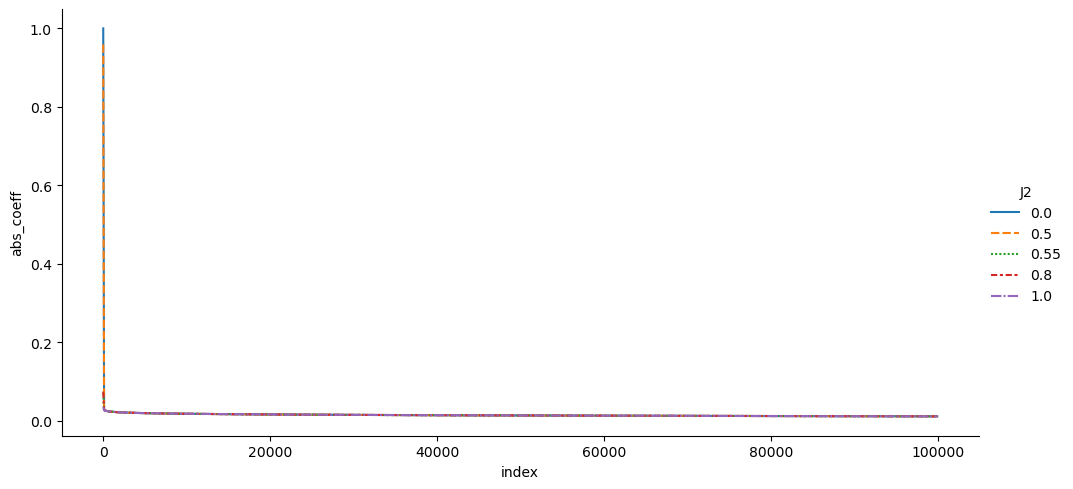

In [87]:
g = visualize_first_coeffs(100_000, step=100_000 // 1000, J2=[0.0, 0.5, 0.55, 0.8, 1.0])

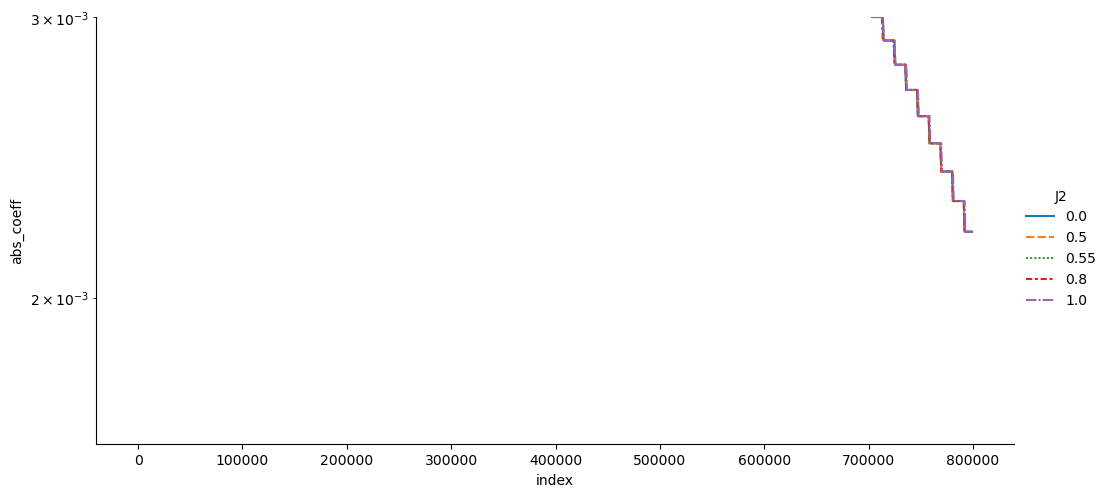

In [86]:
g.set(yscale="log", ylim=(None, 0.003))
g.fig

In [71]:
(learner.get_coeffs_df()).shape

(1056016, 1)

<AxesSubplot: xlabel='J2', ylabel='mean_multiplicity'>

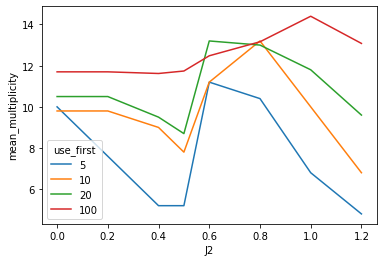

In [39]:
sns.lineplot(
    learner_multipliticities.assign(
        use_first=lambda x: x["keep_first"].astype(str)
    ),
    x="J2",
    y="mean_multiplicity",
    hue="use_first",
)

In [197]:
(learner.get_coeffs_df().assign(multiplicities=multiplicities).iloc[:10])

,coeff,multiplicities
15833190,-0.14092,2
3382374,-0.13592,8
848700,-0.13572,2
848730,-0.13004,8
7572646,-0.12696,4
1993528,-0.12308,4
3762597,-0.12024,8
242487,-0.11556,8
1635149,0.11436,16
1665869,0.11340,8
